In [1]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

seed = 234
rng = np.random.default_rng(seed=seed)

In [2]:
def custom_cosine_similarity(x, y):
    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

In [3]:
exc_fname = Path("/src/project/data/experiment/exc_images_preprocessed.npy")
exc_images = np.load(exc_fname)
print(exc_images.shape)

(960, 36, 36)


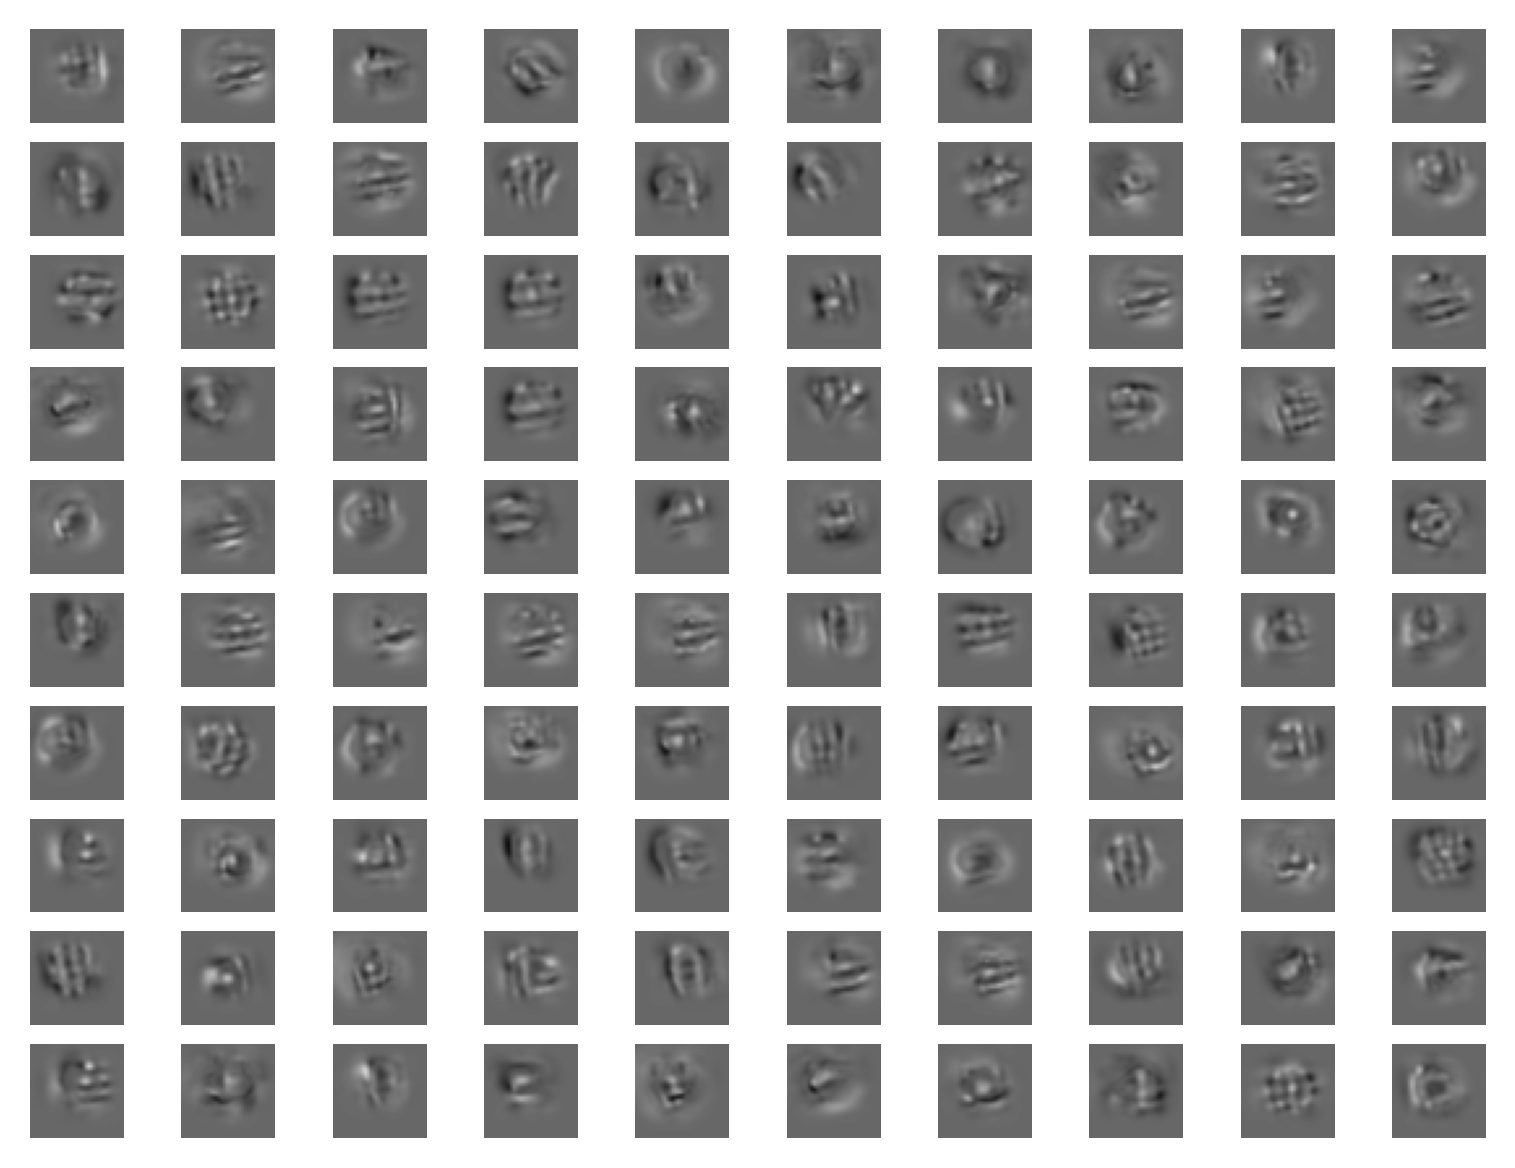

In [4]:
fig, axs = plt.subplots(10, 10, dpi=300)
vmin = np.min(exc_images)
vmax = np.max(exc_images)
for idx, ax in enumerate(axs.flatten()):
    ax.imshow(exc_images[idx], cmap="gray", vmin=vmin, vmax=vmax)
    ax.axis("off")

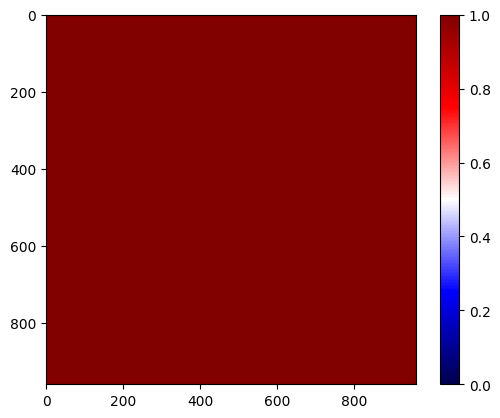

In [5]:
csim_all = cosine_similarity(exc_images.reshape(exc_images.shape[0], -1))
fig, ax = plt.subplots()
im = ax.imshow(csim_all, cmap="seismic", vmin=0, vmax=1)
# plot a colorbar to show the correspondence between values and colors
plt.colorbar(im, ax=ax)

Text(0.5, 1.0, 'Histogram of cosine sim between exc stimuli')

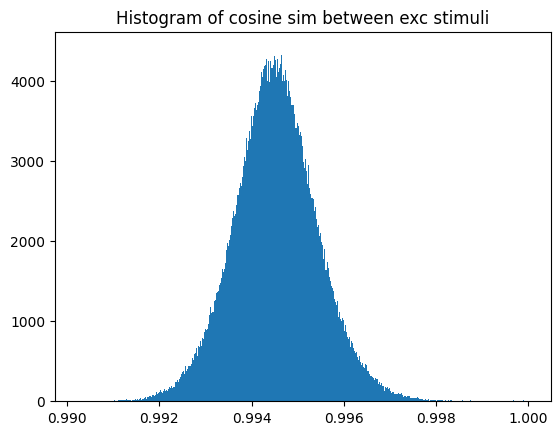

In [6]:
plt.hist(csim_all.flatten(), bins=1000)
plt.title("Histogram of cosine sim between exc stimuli")

(-0.5, 35.5, 35.5, -0.5)

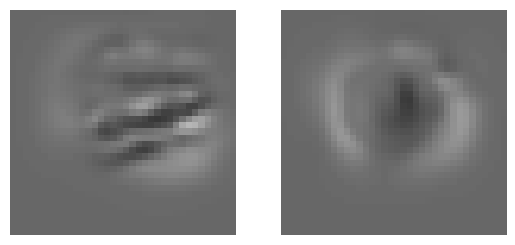

In [7]:
fig, axs = plt.subplots(1, 2)
axs[0].imshow(exc_images[1], cmap="gray", vmin=vmin, vmax=vmax)
axs[0].axis("off")
axs[1].imshow(exc_images[4], cmap="gray", vmin=vmin, vmax=vmax)
axs[1].axis("off")

In [8]:
sample_1 = exc_images[1].reshape(1, -1)
sample_2 = exc_images[4].reshape(1, -1)
csim = cosine_similarity(sample_1.reshape(1, -1), sample_2.reshape(1, -1))[0, 0]
print(f"Cosine sim (sklearn) between sample 1 and 2: {csim}")
print(
    f"Cosine sim (custom) between sample 1 and 2: {custom_cosine_similarity(sample_1.squeeze(), sample_2.squeeze())}"
)

Cosine sim (sklearn) between sample 1 and 2: 0.9964831820309168
Cosine sim (custom) between sample 1 and 2: 0.9964831820309168


Text(0.5, 1.0, 'r^2=0.102   cos=0.319  csim=0.996')

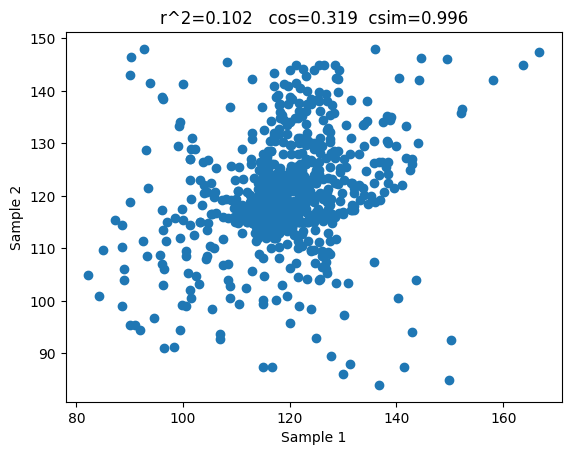

In [9]:
# do a scatter plot of the two images and compute r^2
fig, ax = plt.subplots()
ax.scatter(sample_1, sample_2)
ax.set_xlabel("Sample 1")
ax.set_ylabel("Sample 2")
ax.set_title(
    f"r^2={np.corrcoef(sample_1.squeeze(), sample_2.squeeze())[0, 1] ** 2:.3f}   cos={np.corrcoef(sample_1.squeeze(), sample_2.squeeze())[0, 1]:.3f}  csim={csim:.3f}"
)

Text(0.5, 1.0, 'r^2=0.102   corr=0.319  cos=0.318')

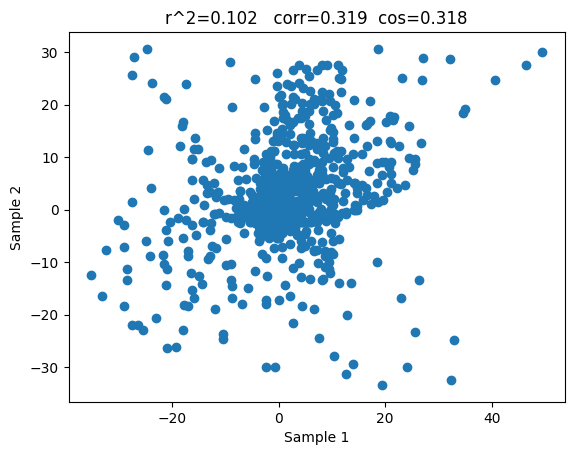

In [10]:
centered_sample_1 = sample_1 - np.mean(np.array([sample_1, sample_2]))
centered_sample_2 = sample_2 - np.mean(np.array([sample_1, sample_2]))

# do a scatter plot of the two images and compute r^2
fig, ax = plt.subplots()
ax.scatter(centered_sample_1, centered_sample_2)
ax.set_xlabel("Sample 1")
ax.set_ylabel("Sample 2")
ax.set_title(
    f"r^2={np.corrcoef(centered_sample_1.squeeze(), centered_sample_2.squeeze())[0, 1] ** 2:.3f}   corr={np.corrcoef(centered_sample_1.squeeze(), centered_sample_2.squeeze())[0, 1]:.3f}  cos={custom_cosine_similarity(centered_sample_1.squeeze(), centered_sample_2.squeeze()):.3f}"
)

In [11]:
exc_images_mean = np.mean(exc_images, axis=0)

In [12]:
centered_data = exc_images - exc_images_mean

Text(0.5, 1.0, 'Cosine sim between exc stimuli after centering')

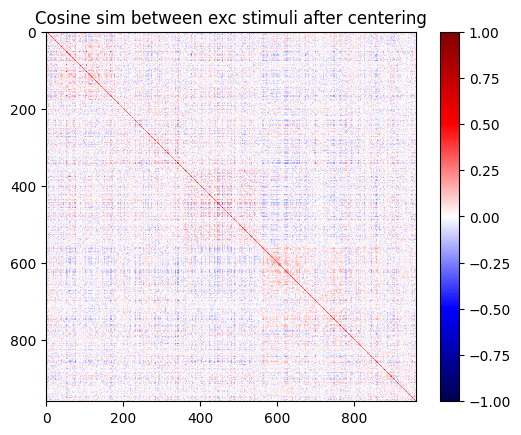

In [13]:
csim_centered = cosine_similarity(centered_data.reshape(centered_data.shape[0], -1))
fig, ax = plt.subplots()
im = ax.imshow(csim_centered, cmap="seismic", vmin=-1, vmax=1)
# plot a colorbar to show the correspondence between values and colors
plt.colorbar(im, ax=ax)
plt.title("Cosine sim between exc stimuli after centering")

In [17]:
csim_centered = cosine_similarity(
    centered_data[:4].reshape(centered_data[:4].shape[0], -1)
)

Text(0.5, 1.0, 'Cosine sim between exc stimuli after centering')

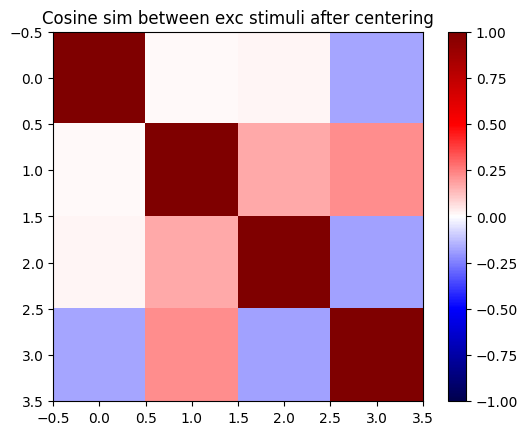

In [18]:
fig, ax = plt.subplots()
im = ax.imshow(csim_centered, cmap="seismic", vmin=-1, vmax=1)
# plot a colorbar to show the correspondence between values and colors
plt.colorbar(im, ax=ax)
plt.title("Cosine sim between exc stimuli after centering")

Text(0.5, 1.0, 'Histogram of cosine sim between exc stimuli after centering')

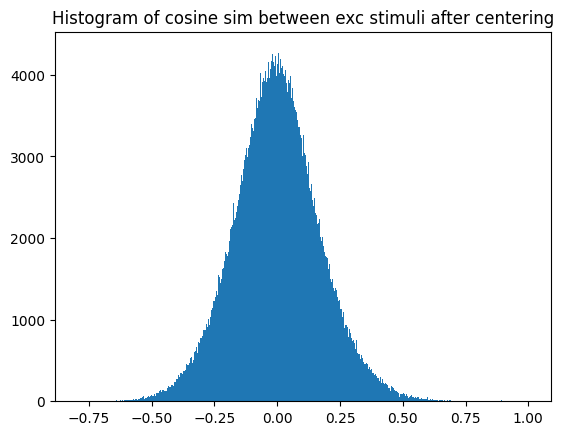

In [14]:
plt.hist(csim_centered.flatten(), bins=1000)
plt.title("Histogram of cosine sim between exc stimuli after centering")

Text(0.5, 1.0, 'r^2=0.004   corr=-0.061  cos=0.669')

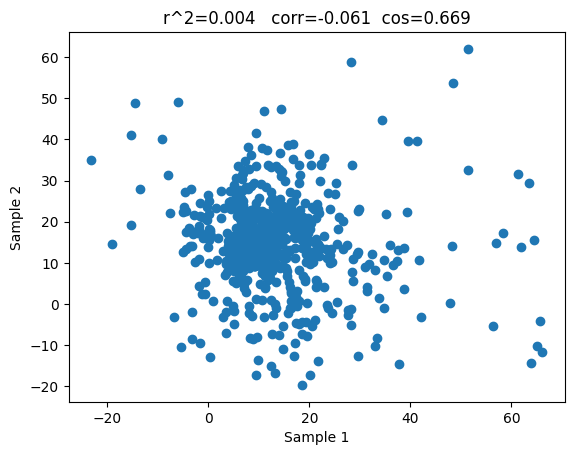

In [15]:
centered_sample_1 = centered_data[0].reshape(1, -1) + 10
centered_sample_2 = centered_data[1].reshape(1, -1) + 10

corr = np.corrcoef(centered_sample_1.squeeze(), centered_sample_2.squeeze())[0, 1]
r2 = corr**2
cos = cosine_similarity(centered_sample_1, centered_sample_2)[0, 0]

# do a scatter plot of the two images and compute r^2
fig, ax = plt.subplots()
ax.scatter(centered_sample_1, centered_sample_2)
ax.set_xlabel("Sample 1")
ax.set_ylabel("Sample 2")
ax.set_title(f"r^2={r2:.3f}   corr={corr:.3f}  cos={cos:.3f}")

In [16]:
offsets = np.linspace(0, 10, 100)
cos_list_0 = []
for offset in offsets:
    centered_sample_1 = centered_data[0].reshape(1, -1) + offset
    centered_sample_2 = centered_data[1].reshape(1, -1) + offset
    cos = cosine_similarity(centered_sample_1, centered_sample_2)[0, 0]
    cos_list_0.append(cos)

In [18]:
offsets = np.linspace(0, 10, 100)
cos_list_1 = []
for offset in offsets:
    centered_sample_1 = centered_data[4].reshape(1, -1) + offset
    centered_sample_2 = centered_data[1].reshape(1, -1) + offset
    cos = cosine_similarity(centered_sample_1, centered_sample_2)[0, 0]
    cos_list_1.append(cos)

(-0.5, 35.5, 35.5, -0.5)

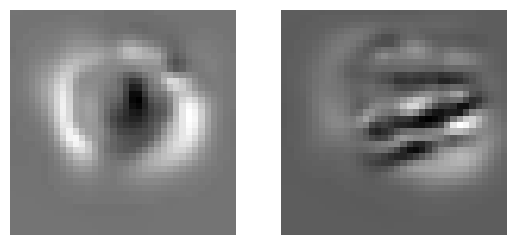

In [19]:
fig, axs = plt.subplots(1, 2)
axs[0].imshow(centered_data[4], cmap="gray")
axs[0].axis("off")
axs[1].imshow(centered_data[1], cmap="gray")
axs[1].axis("off")

(-0.5, 35.5, 35.5, -0.5)

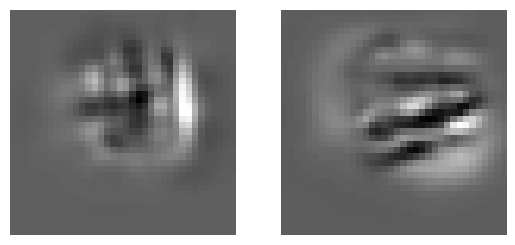

In [20]:
fig, axs = plt.subplots(1, 2)
axs[0].imshow(centered_data[0], cmap="gray")
axs[0].axis("off")
axs[1].imshow(centered_data[1], cmap="gray")
axs[1].axis("off")

Text(0, 0.5, 'Cosine similarity')

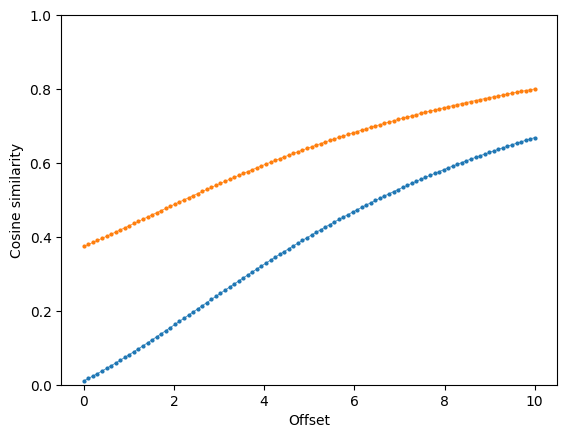

In [21]:
plt.plot(offsets, cos_list_0, marker="o", markersize=2, linewidth=0.5)
plt.plot(offsets, cos_list_1, marker="o", markersize=2, linewidth=0.5)
plt.xlabel("Offset")
plt.ylim(0, 1)
plt.ylabel("Cosine similarity")